# EMNIST — Custom Training Loop avec Keras + PyTorch backend
Architecture CNN entraînée sur le split `byclass` (62 classes : chiffres + lettres majuscules/minuscules).  
Boucle d'entraînement bas-niveau inspirée du guide officiel Keras.

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"  # Keras utilise PyTorch comme backend

import torch
import keras
import numpy as np
from torchvision.datasets import EMNIST
from torchvision.transforms import v2
from torch.utils.data import DataLoader

print(f"Keras version  : {keras.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"Device         : {'cuda' if torch.cuda.is_available() else 'cpu'}")

Keras version  : 3.14.0
PyTorch version: 2.11.0+cu126
Device         : cuda


## 1. Chargement & transformations EMNIST

In [3]:
# --- Transformations ---
# EMNIST est stocké transposé → flip + rotation pour corriger l'orientation
tran_train = v2.Compose([
    v2.RandomHorizontalFlip(p=1.0),           # correction EMNIST
    v2.RandomRotation(degrees=(90, 90)),       # correction EMNIST
    v2.RandomRotation(degrees=(-10, 10)),      # augmentation légère
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),     # [0, 1]
    v2.Normalize(mean=[0.1307], std=[0.3081])  # normalisation MNIST/EMNIST standard
])

tran_test = v2.Compose([
    v2.RandomHorizontalFlip(p=1.0),
    v2.RandomRotation(degrees=(90, 90)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.1307], std=[0.3081])
])

# --- Datasets (byclass = 62 classes) ---
train_data = EMNIST(root="data", split="byclass", train=True,  transform=tran_train, download=True)
test_data  = EMNIST(root="data", split="byclass", train=False, transform=tran_test,  download=True)

print(f"Train samples : {len(train_data):,}")
print(f"Test  samples : {len(test_data):,}")
print(f"Nb classes    : {len(train_data.classes)}")

Train samples : 697,932
Test  samples : 116,323
Nb classes    : 62


In [4]:
BATCH_SIZE = 64

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Batches train : {len(train_loader):,}")
print(f"Batches test  : {len(test_loader):,}")

Batches train : 10,906
Batches test  : 1,818


## 2. Visualisation rapide

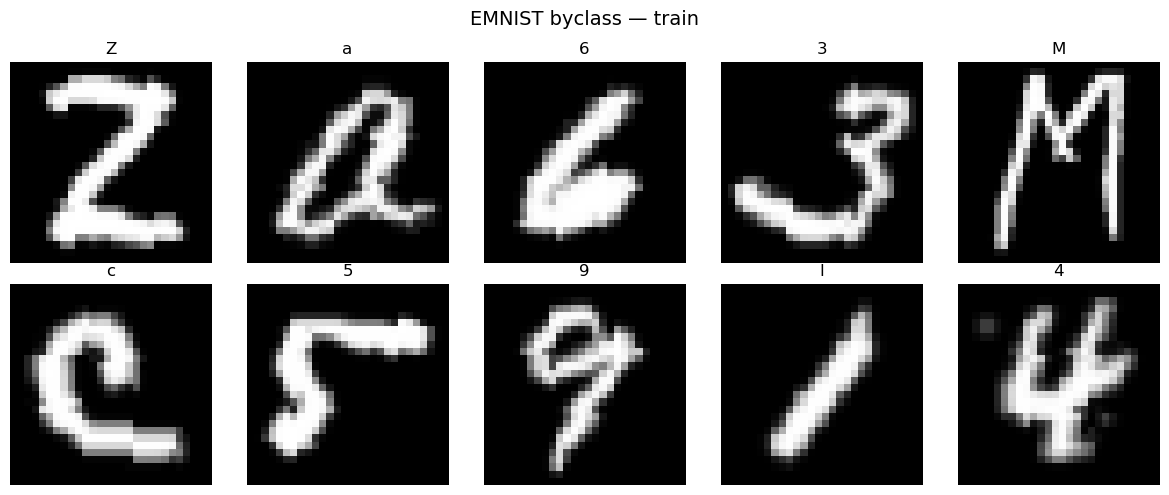

In [5]:
import matplotlib.pyplot as plt

def show_images(dataset, main_title="EMNIST byclass", n=10):
    fig, axes = plt.subplots(2, n // 2, figsize=(12, 5))
    fig.suptitle(main_title, fontsize=14)
    for ax, (img, label) in zip(axes.flat, dataset):
        # (1, 28, 28) → (28, 28)
        ax.imshow(img.permute(1, 2, 0).squeeze(), cmap="gray")
        ax.set_title(dataset.classes[label])
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_images(train_data, main_title="EMNIST byclass — train")

## 3. Modèle CNN avec Keras (backend PyTorch)

Architecture **3 blocs convolutifs** (Conv → BatchNorm → MaxPool) suivis d'une tête dense.
Chaque bloc double le nombre de filtres (32 → 64 → 128) pour capturer des features de plus en plus abstraites.
Le troisième bloc n'a pas de MaxPool : la carte spatiale est déjà à 7×7 et un pooling supplémentaire
détruirait trop d'information.

La sortie est des **logits bruts** (pas de softmax) — la CrossEntropy l'applique en interne de façon plus stable numériquement.


In [6]:
NUM_CLASSES = 62  # byclass : 10 chiffres + 26 maj + 26 min

class EMNISTModel(keras.Model):
    """CNN 3 blocs pour la classification de caractères EMNIST 28×28 → 62 classes.

    Entrée : tensor (batch, 1, 28, 28) au format PyTorch (channels-first).
    Le transpose dans call() convertit vers le format Keras (channels-last).
    """

    def __init__(self, num_classes: int = NUM_CLASSES):
        super().__init__()

        # Bloc convolutif 1 : 1 → 32
        self.conv1 = keras.layers.Conv2D(32, kernel_size=10, padding="same", activation="relu")
        self.bn1   = keras.layers.BatchNormalization()
        self.pool1 = keras.layers.MaxPooling2D(pool_size=2)  # 28 → 14

        # Bloc convolutif 2 : 32 → 64
        self.conv2 = keras.layers.Conv2D(64, kernel_size=5, padding="same", activation="relu")
        self.bn2   = keras.layers.BatchNormalization()
        self.pool2 = keras.layers.MaxPooling2D(pool_size=2)  # 14 → 7

        # Bloc convolutif 3 : 64 → 128  
        self.conv3 = keras.layers.Conv2D(128, kernel_size=3, padding="same", activation="relu")
        self.bn3   = keras.layers.BatchNormalization()

        # Tête de classification
        self.flatten  = keras.layers.Flatten()               # 7×7×128 = 6272
        self.dropout  = keras.layers.Dropout(0.2)
        self.fc1      = keras.layers.Dense(7*128, activation="relu")
        self.fc2      = keras.layers.Dense(128, activation="relu")
        self.fc3      = keras.layers.Dense(num_classes)       # logits (pas de softmax)

    def call(self, x, training=False):
        # x : (batch, 1, 28, 28)  →  Keras attend (batch, H, W, C)
        x = keras.ops.transpose(x, axes=(0, 2, 3, 1))

        x = self.pool1(self.bn1(self.conv1(x), training=training))
        x = self.pool2(self.bn2(self.conv2(x), training=training))
        x = self.bn3(self.conv3(x), training=training)

        x = self.flatten(x)
        x = self.dropout(x, training=training)
        x = self.fc1(x)
        x = self.fc2(x)
        return self.fc3(x)


model = EMNISTModel()

# Build pour afficher le summary
dummy = torch.zeros(1, 1, 28, 28)
_ = model(dummy)
model.summary()


Model: "emnist_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (1, 28, 28, 32)        │         3,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (1, 28, 28, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (1, 14, 14, 64)        │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (1, 14, 14, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (1, 7, 7, 128)         │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (1, 7, 7, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (1, 6272)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 896)               │     5,620,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 128)               │       114,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (1, 62)                │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,872,670 (22.40 MB)

 Trainable params: 5,872,222 (22.40 MB)

 Non-trainable params: 448 (1.75 KB)

## 4. Boucle d'entraînement custom (style guide Keras officiel)

La boucle gère manuellement le calcul des gradients pour garder le contrôle sur chaque étape.
Particularité de l'intégration Keras + PyTorch :
- `loss_fn` et les métriques sont **Keras** (API haut niveau, plus lisible)
- `loss.backward()` est **PyTorch** (calcul des gradients via autograd)
- `optimizer.apply()` est **Keras**, mais doit être appelé dans un `torch.no_grad()` pour éviter de tracer les mises à jour

Un mécanisme d'**early stopping** (patience=3) arrête l'entraînement si la val_acc ne progresse pas,
et sauvegarde uniquement le meilleur checkpoint.


In [ ]:
# --- Hyperparamètres ---
NUM_EPOCHS   = 10
LEARNING_RATE = 1e-3
LOG_EVERY     = 500   # afficher la loss tous les N batches

# --- Optimizer & Loss Keras ---
optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
loss_fn   = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# --- Métriques Keras ---
train_acc_metric = keras.metrics.SparseCategoricalAccuracy()
val_acc_metric   = keras.metrics.SparseCategoricalAccuracy()

# --- Learning Rate Scheduler (réduction sur plateau) ---
best_val_acc = 0.0
patience_counter = 0
PATIENCE = 3

history = {"train_loss": [], "train_acc": [], "val_acc": []}

# =====================================================================
#  BOUCLE PRINCIPALE
# =====================================================================
for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}")
    print(f"{'='*60}")

    model.zero_grad()  # nettoyage initial
    running_loss = 0.0

    # ── Phase d'entraînement ──────────────────────────────────────────────
    for step, (images, labels) in enumerate(train_loader):

        # Forward pass — training=True active le BatchNorm et le Dropout
        logits = model(images, training=True)
        loss   = loss_fn(labels, logits)           # Keras attend (y_true, y_pred)

        # Backward pass via PyTorch autograd
        # zero_grad() efface les gradients du batch précédent avant d'appeler backward()
        model.zero_grad()
        trainable_weights = list(model.trainable_weights)
        loss.backward()
        gradients = [v.value.grad for v in trainable_weights]  # gradients extraits des variables Keras

        # Mise à jour des poids via l'optimizer Keras
        # torch.no_grad() empêche PyTorch de tracer ces opérations dans le graphe
        with torch.no_grad():
            optimizer.apply(gradients, trainable_weights)

        # Métriques
        train_acc_metric.update_state(labels, logits)
        running_loss += loss.detach().item()

        if step % LOG_EVERY == 0:
            avg_loss = running_loss / (step + 1)
            print(f"  Step {step:>5} | Loss: {avg_loss:.4f} | "
                  f"Acc: {float(train_acc_metric.result()):.4f}")

    # Résultats epoch train
    epoch_loss = running_loss / len(train_loader)
    epoch_acc  = float(train_acc_metric.result())
    train_acc_metric.reset_state()

    history["train_loss"].append(epoch_loss)
    history["train_acc"].append(epoch_acc)
    print(f"\n→ Train  | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

    # ── Phase de validation (pas de gradient, training=False) ─────────────
    for images, labels in test_loader:
        val_logits = model(images, training=False)
        val_acc_metric.update_state(labels, val_logits)

    val_acc = float(val_acc_metric.result())
    val_acc_metric.reset_state()
    history["val_acc"].append(val_acc)
    print(f"→ Val    | Acc: {val_acc:.4f}")

    # ── Sauvegarde du meilleur checkpoint + early stopping ────────────────
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        model.save_weights("best_emnist_model.weights.h5")
        print(f" Nouveau meilleur modèle sauvegardé (val_acc={best_val_acc:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f" Pas d'amélioration ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print("  Early stopping déclenché.")
            break

print(f"\nMeilleure val_acc : {best_val_acc:.4f}")



Epoch 1/10
  Step     0 | Loss: 5.0248 | Acc: 0.0000
  Step   500 | Loss: 0.9807 | Acc: 0.7150
  Step  1000 | Loss: 0.7979 | Acc: 0.7558
  Step  1500 | Loss: 0.7147 | Acc: 0.7753
  Step  2000 | Loss: 0.6642 | Acc: 0.7868
  Step  2500 | Loss: 0.6305 | Acc: 0.7952
  Step  3000 | Loss: 0.6068 | Acc: 0.8011
  Step  3500 | Loss: 0.5887 | Acc: 0.8057
  Step  4000 | Loss: 0.5728 | Acc: 0.8098
  Step  4500 | Loss: 0.5611 | Acc: 0.8131
  Step  5000 | Loss: 0.5504 | Acc: 0.8159
  Step  5500 | Loss: 0.5413 | Acc: 0.8180
  Step  6000 | Loss: 0.5336 | Acc: 0.8200
  Step  6500 | Loss: 0.5270 | Acc: 0.8216
  Step  7000 | Loss: 0.5197 | Acc: 0.8233
  Step  7500 | Loss: 0.5147 | Acc: 0.8246
  Step  8000 | Loss: 0.5089 | Acc: 0.8262
  Step  8500 | Loss: 0.5045 | Acc: 0.8274
  Step  9000 | Loss: 0.4997 | Acc: 0.8285
  Step  9500 | Loss: 0.4956 | Acc: 0.8298
  Step 10000 | Loss: 0.4914 | Acc: 0.8310
  Step 10500 | Loss: 0.4881 | Acc: 0.8317

→ Train  | Loss: 0.4852 | Acc: 0.8325
→ Val    | Acc: 0.8588
  

KeyboardInterrupt: 

## 5. Courbes d'entraînement

In [7]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_acc"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], marker="o", label="Train Acc")
axes[1].plot(epochs_range, history["val_acc"],   marker="s", label="Val Acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

NameError: name 'history' is not defined

## 6. Évaluation finale (meilleur checkpoint)

In [8]:
# Rechargement du meilleur checkpoint avant l'évaluation finale
# (les poids courants peuvent être ceux d'une epoch moins bonne si l'early stopping s'est déclenché)
model.load_weights("best_emnist_model.weights.h5")

eval_metric = keras.metrics.SparseCategoricalAccuracy()

for images, labels in test_loader:
    logits = model(images, training=False)
    eval_metric.update_state(labels, logits)

final_acc = float(eval_metric.result())
print(f"Accuracy finale sur le test set : {final_acc * 100:.2f}%")


ValueError: A total of 5 objects could not be loaded. Example error message for object <Conv2D name=conv2d, built=True>:

Layer 'conv2d' expected 2 variables, but received 0 variables during loading. Expected: ['kernel', 'bias']

List of objects that could not be loaded:
[<Conv2D name=conv2d, built=True>, <Conv2D name=conv2d_1, built=True>, <Dense name=dense, built=True>, <Dense name=dense_1, built=True>, <Dense name=dense_2, built=True>]

## 7. Inférence — visualiser les prédictions

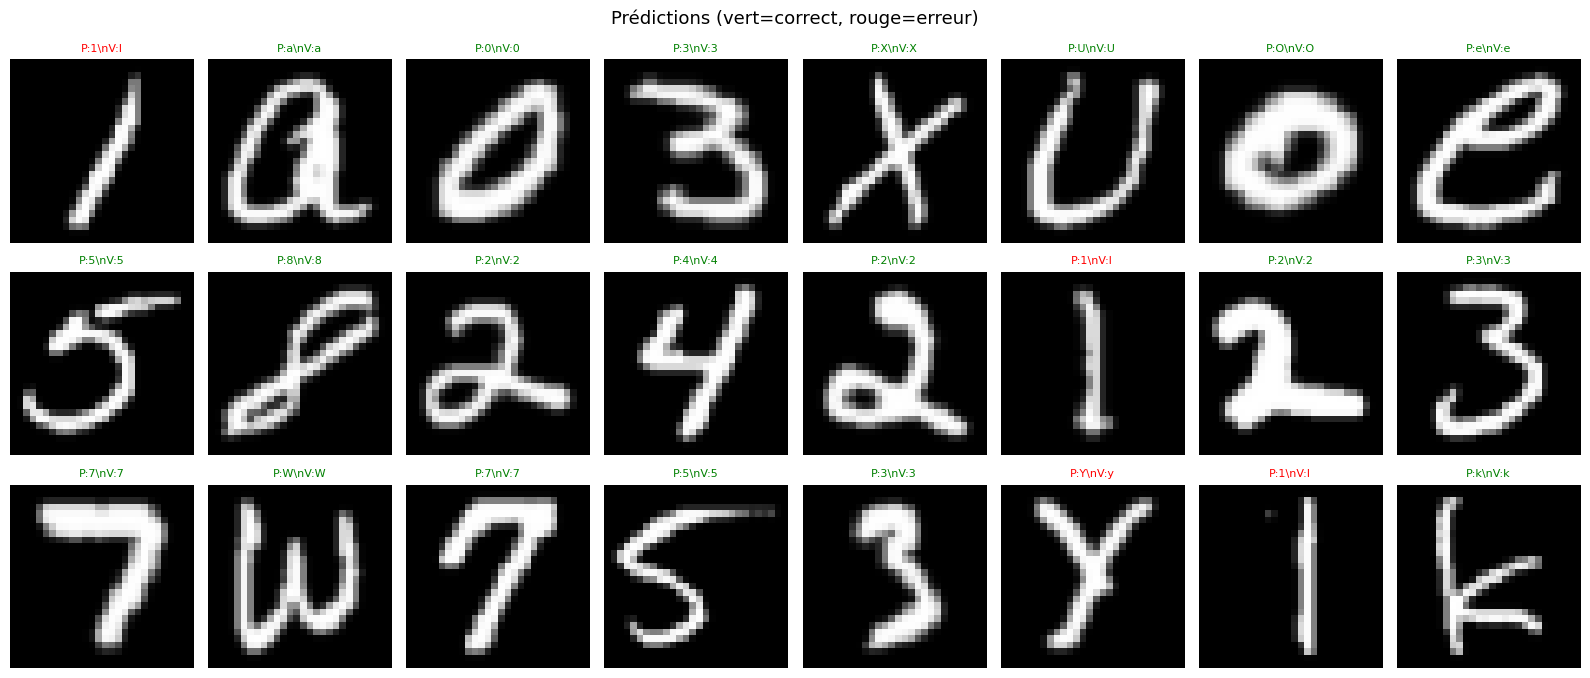

In [ ]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

classes = test_data.classes

images, labels = next(iter(test_loader))

with torch.no_grad():
    logits = model(images, training=False)
    probs = F.softmax(torch.tensor(logits.cpu().numpy()), dim=1)
    preds = probs.argmax(dim=1)

fig, axes = plt.subplots(3, 8, figsize=(16, 7))
for ax, img, pred, true in zip(axes.flat, images.cpu(), preds, labels):
    ax.imshow(img.permute(1, 2, 0).squeeze(), cmap="gray")
    color = "green" if pred.item() == true.item() else "red"
    ax.set_title(f"P:{classes[pred]}\\nV:{classes[true]}", color=color, fontsize=8)
    ax.axis("off")

plt.suptitle("Prédictions (vert=correct, rouge=erreur)", fontsize=13)
plt.tight_layout()
plt.show()